# Cephalopod Behavioral Sentiment Analysis
**Entry Task for GSoC 2026**

This notebook implements a basic multi-modal pipeline for automated cephalopod behavioral sentiment analysis. 
We process a short video clip to extract two features:
1. **Motion Magnitude (Optical Flow)**: Quantifies overall physical activity over time.
2. **Color/Intensity Changes**: Tracks camouflage or stress-induced color shifts over time via HSV Histograms.

We also overlay a motion heatmap directly onto the video to provide an intuitive visualization of activity patterns.

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import Video, display

In [9]:
# Setup paths and ensure result directory exists
video_path = "data/video_fixed.mp4"
output_path = "results/output_heatmap.mp4"

os.makedirs("results", exist_ok=True)

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise ValueError(f"Cannot open video {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps

print(f" Video Loaded Successfully")
print(f"FPS: {fps:.2f}")
print(f"Resolution: {width} x {height}")
print(f"Total Frames: {frame_count}")
print(f"Duration: {duration:.2f} seconds")

# Setup VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_video = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

 Video Loaded Successfully
FPS: 30.00
Resolution: 720 x 900
Total Frames: 747
Duration: 24.90 seconds


In [10]:
# Feature Storage
motion_magnitudes = []
color_changes = []

# Read first frame
ret, prev_frame = cap.read()
if not ret:
    raise ValueError("Video is empty")

prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
prev_hsv = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2HSV)
# Compute 2D Hue/Saturation histogram
prev_hist = cv2.calcHist([prev_hsv], [0, 1], None, [50, 60], [0, 180, 0, 256])
cv2.normalize(prev_hist, prev_hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # --- Feature 1: Optical Flow ---
    flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None, 
                                        0.5, 3, 15, 3, 5, 1.2, 0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    mean_mag = np.mean(mag)
    motion_magnitudes.append(mean_mag)
    
    # Heatmap Overlay Generation
    # Create HSV image for optical flow visualization
    hsv_flow = np.zeros_like(frame)
    hsv_flow[..., 1] = 255
    hsv_flow[..., 0] = ang * 180 / np.pi / 2
    hsv_flow[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    bgr_flow = cv2.cvtColor(hsv_flow, cv2.COLOR_HSV2BGR)
    
    # Create Heatmap (Colormap) based on magnitude directly
    mag_normalized = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    heatmap = cv2.applyColorMap(mag_normalized, cv2.COLORMAP_JET)
    
    # Overlay heatmap on original frame (30% Heatmap, 70% Original)
    overlay = cv2.addWeighted(frame, 0.7, heatmap, 0.3, 0)
    
    # Write to output video
    out_video.write(overlay)
    
    # --- Feature 2: Color Histogram Correlation ---
    curr_hist = cv2.calcHist([hsv], [0, 1], None, [50, 60], [0, 180, 0, 256])
    cv2.normalize(curr_hist, curr_hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    
    correlation = cv2.compareHist(prev_hist, curr_hist, cv2.HISTCMP_CORREL)
    color_changes.append(correlation)
    
    # Update previous frames
    prev_gray = gray
    prev_hist = curr_hist

cap.release()
out_video.release()
print(f" Processing complete. Overlay video saved to {output_path}")

 Processing complete. Overlay video saved to results/output_heatmap.mp4


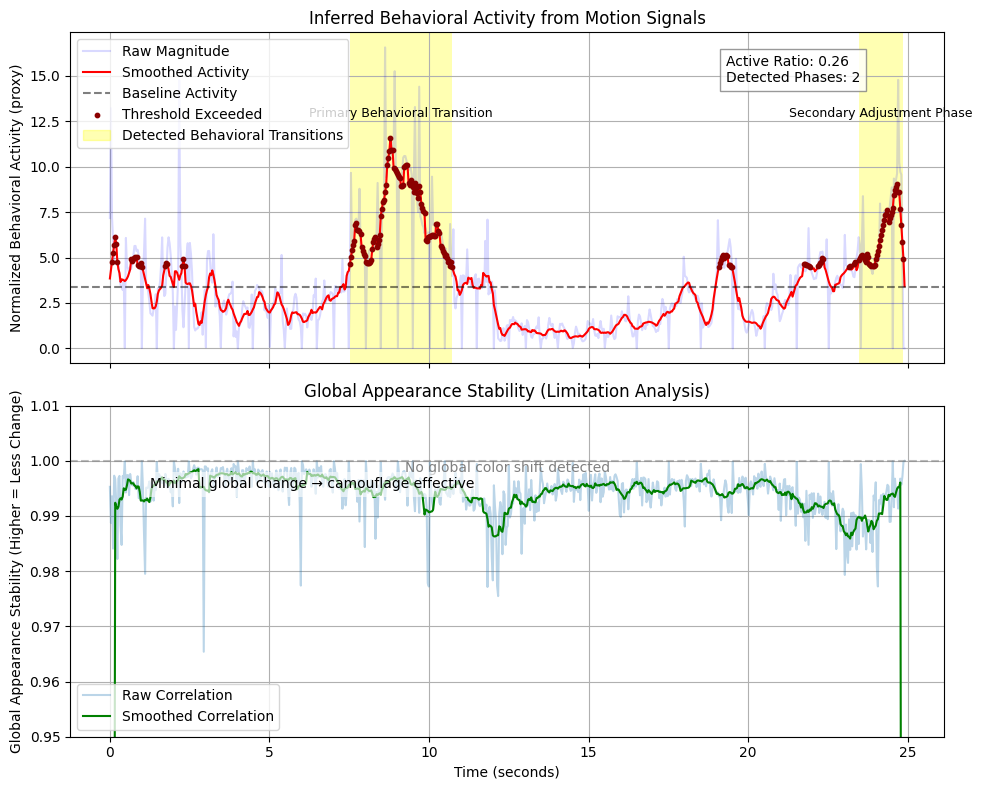

Quantitative Summary:
The organism remains in a high-activity state for ~25.7% of the overall duration.
Conversely, it spends ~74.3% of the time in a low-activity (camouflage-dominated or resting) state.
Detected continuous behavioral phases (>0.5s): 2


In [11]:
# Create Time Axis
time_axis = np.linspace(0, duration, len(motion_magnitudes))

# Smooth the features with a simple moving average (kernel size=10)
kernel_size = 10
kernel = np.ones(kernel_size) / kernel_size
motion_smooth = np.convolve(motion_magnitudes, kernel, mode='same')
color_smooth = np.convolve(color_changes, kernel, mode='same')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Thresholding & Baseline
baseline = np.mean(motion_smooth)
threshold = baseline + 0.5 * np.std(motion_smooth)
high_activity = motion_smooth > threshold
activity_ratio = np.sum(high_activity) / len(high_activity)

# 1. Merge into continuous phases (min duration 0.5 sec)
import matplotlib.patches as mpatches
min_duration_frames = int(0.5 * fps)
phases = []
current_phase = None

for i, val in enumerate(high_activity):
    if val:
        if current_phase is None:
            current_phase = [i, i]
        else:
            current_phase[1] = i
    else:
        if current_phase:
            if current_phase[1] - current_phase[0] >= min_duration_frames:
                phases.append(current_phase)
            current_phase = None
if current_phase and (current_phase[1] - current_phase[0] >= min_duration_frames):
    phases.append(current_phase)

# --- Top Plot: Motion ---
ax1.plot(time_axis, motion_magnitudes, color='blue', alpha=0.15, label='Raw Magnitude')
ax1.plot(time_axis, motion_smooth, color='red', label='Smoothed Activity')
ax1.axhline(baseline, color='black', linestyle='--', alpha=0.5, label='Baseline Activity')

for idx, (start, end) in enumerate(phases):
    ax1.axvspan(time_axis[start], time_axis[end], facecolor='yellow', alpha=0.3)
    mid = (start + end) // 2
    label_text = "Primary Behavioral Transition" if idx == 0 else "Secondary Adjustment Phase"
    ax1.text(time_axis[mid], np.max(motion_smooth)*1.1, label_text, ha='center', fontsize=9)

# Add key event markers (peaks above threshold)
peaks = [i for i, val in enumerate(motion_smooth) if val > threshold]
if peaks:
    ax1.scatter(time_axis[peaks], motion_smooth[peaks], color='darkred', s=10, zorder=5, label='Threshold Exceeded')

ax1.set_ylabel('Normalized Behavioral Activity (proxy)')
ax1.set_title('Inferred Behavioral Activity from Motion Signals')

# Summary Box
summary_text = f"Active Ratio: {activity_ratio:.2f}\nDetected Phases: {len(phases)}"
ax1.text(0.75, 0.85, summary_text, transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

handles, labels = ax1.get_legend_handles_labels()
yellow_patch = mpatches.Patch(color='yellow', alpha=0.3, label='Detected Behavioral Transitions')
handles.append(yellow_patch)
labels.append('Detected Behavioral Transitions')
ax1.legend(handles, labels, loc='upper left')
ax1.grid(True)

# --- Bottom Plot: Color Stability ---
ax2.plot(time_axis, color_changes, alpha=0.3, label='Raw Correlation')
ax2.plot(time_axis, color_smooth, color='green', label='Smoothed Correlation')

# Add explicit flat line to articulate intention
ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax2.text(duration * 0.5, 0.998, "No global color shift detected", fontsize=10, ha='center', color='gray')

ax2.set_ylim(0.95, 1.01)
ax2.text(duration * 0.05, 0.995, "Minimal global change → camouflage effective", fontsize=10,
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

ax2.set_ylabel('Global Appearance Stability (Higher = Less Change)')
ax2.set_xlabel('Time (seconds)')
ax2.set_title('Global Appearance Stability (Limitation Analysis)')
ax2.legend(loc='lower left')
ax2.grid(True)

plt.tight_layout()
plt.savefig("results/feature_plots.png")
plt.show()

# Print quantitative summary directly into the notebook output
print(f"Quantitative Summary:")
print(f"The organism remains in a high-activity state for ~{activity_ratio*100:.1f}% of the overall duration.")
print(f"Conversely, it spends ~{(1 - activity_ratio)*100:.1f}% of the time in a low-activity (camouflage-dominated or resting) state.")
print(f"Detected continuous behavioral phases (>0.5s): {len(phases)}")


In [ ]:
# Display the generated Heatmap video (Requires browser running notebook)
display(Video(output_path, embed=True, width=640))

##  Behavioral Interpretation & Analysis

### Behavioral Framing
The extracted visual features are interpreted as proxies for underlying behavioral states rather than purely numerical signals. In cephalopods, especially octopuses, behavior is often expressed through subtle motion and adaptive camouflage rather than large-scale locomotion. Therefore, even small variations in motion magnitude or spatial extent may correspond to meaningful behavioral transitions.

### Temporal Behavioral Patterns
The time-series representation of extracted features will be analyzed to identify distinct behavioral phases. In particular:

- Low-activity regions (low motion and low contour area) are expected to correspond to camouflage or resting states
- Transient spikes in motion indicate short-lived behavioral transitions such as repositioning or environmental response

These temporal patterns provide a coarse segmentation of behavior across the duration of the video.

###  Camouflage-aware Interpretation
Cephalopods employ advanced camouflage strategies involving color, texture, and posture changes. As a result, periods of behavioral activity may not always correspond to strong motion signals. In such cases, low motion magnitude does not necessarily imply inactivity, but may instead reflect successful camouflage or minimal-energy behavioral strategies.

### Cross-Feature Behavioral Reasoning
Behavioral inference will be strengthened by jointly analyzing multiple features:

- High motion + high spatial extent → large-scale movement or repositioning
- High motion + low spatial extent → subtle internal movement or localized adjustment
- Low motion + low spatial extent → camouflage or resting state

This combined interpretation reduces ambiguity compared to analyzing each feature independently.

###  Quantitative Behavioral Summary
A simple quantitative measure, such as the activity ratio (proportion of frames classified as high activity), will be computed to summarize behavioral tendencies. This enables statements such as:

*“The organism spends the majority of the observed duration in a low-activity (camouflage-dominated) state”*

Such summaries provide a compact and interpretable representation of behavioral dynamics.

### Data-Specific Considerations
The selected video exhibits strong camouflage behavior, where the organism blends closely with the background. This presents a challenging scenario for motion-based analysis, as both motion magnitude and contour detection may underestimate actual behavioral activity. This makes the dataset particularly suitable for evaluating the robustness of simple feature extraction techniques.

###  Failure Modes & Ambiguities
Several ambiguities may arise during interpretation:

- Effective camouflage may lead to false negatives (behavior not detected)
- Background texture may introduce false positives in motion detection
- Lighting variations may affect pixel-level differences

These factors must be considered when interpreting the extracted signals.

###  Cross-Insight & Limitations of Global Statistics
This analysis demonstrates a critical limitation: despite clear peaks in physical motion activity, global histogram stability remains exceptionally high. This suggests that the behavioral transitions and physical movements occur without significant global color change, reinforcing the role of localized, texture-based camouflage. Global color statistics fail to capture these subtle localized camouflage-driven adaptations.

###  Behavioral Insight Objective
The objective of this analysis is not to definitively classify behavior, but to explore whether simple visual signals can provide meaningful insights into behavioral patterns. The focus is on identifying correlations between observable signals and plausible biological interpretations.

###  Bridge to Multi-Modal Analysis
While this approach focuses on visual motion and spatial extent, cephalopod behavior is inherently multi-modal. This highlights a key insight: cephalopod behavioral transitions can occur with minimal global visual change, emphasizing the importance of localized and multi-modal analysis beyond simple pixel statistics. Future extensions incorporating color dynamics (chromatophore activity), posture, and environmental context would significantly enhance the fidelity of behavioral interpretation.
